# B29 Corridor — MLP Regressor für Kraftstoffpreise 
**Strecke:** Aalen → Schwäbisch Gmünd → Schorndorf → Stuttgart  
**Ziel:** Stündliche Kraftstoffpreise je Cluster vorhersagen (72h-Horizont) um den optimalen Tankzeitpunkt auf der B29 zu identifizieren.Vorgehen nach CRISP-DM (6 Phasen).

In [1]:
import sys, os
sys.path.insert(0, '..')
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scripts.data_transform import B29DataLoader, B29_CLUSTERS_DEFAULT

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
SEED = 42
TARGET_HORIZON = 72
DATA_START_DATE = "2014-06-09"
DATA_END_DATE = "2026-04-01"

# --- Plot-Speicher-Funktion ---
project_root = os.path.abspath(os.path.join('..'))
docs_path = os.path.join(project_root, 'docs')
os.makedirs(docs_path, exist_ok=True)
fig_id = 1

def save_plot(plt, title_suffix=''):
    global fig_id
    ts = datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
    path = os.path.join(docs_path, f'{ts}_{title_suffix}_{fig_id}.png')
    plt.savefig(path, dpi=plt.rcParams['figure.dpi'], bbox_inches='tight')
    print(f'Plot saved: {path}')
    fig_id += 1

print('Imports OK')

Imports OK


### Hilfsfunktionen
Zentrale Metriken-Berechnung und Persistence-Baseline als wiederverwendbare Funktionen, um Code-Duplikation zu vermeiden.

In [2]:
def compute_metrics_by_horizon(y_true, y_pred, base_targets, horizon):
    """Berechnet MAE, RMSE, R² je Vorhersage-Horizont (1..horizon)."""
    rows = []
    for step in range(1, horizon + 1):
        cols = [f'{c}_t+{step}h' for c in base_targets]
        mae  = mean_absolute_error(y_true[cols], y_pred[cols], multioutput='uniform_average')
        rmse = np.sqrt(mean_squared_error(y_true[cols], y_pred[cols], multioutput='uniform_average'))
        r2   = r2_score(y_true[cols], y_pred[cols], multioutput='uniform_average')
        rows.append({'horizon_h': step, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return pd.DataFrame(rows).set_index('horizon_h')


def build_persistence_baseline(X_data, y_data, base_targets, horizon):
    """Persistence-Baseline: aktueller Preis als Vorhersage für alle Horizonte."""
    pred = pd.DataFrame(index=y_data.index, columns=y_data.columns, dtype=float)
    for step in range(1, horizon + 1):
        for cluster in base_targets:
            pred[f'{cluster}_t+{step}h'] = X_data[f'{cluster}_price_t'].values
    return pred


def print_metrics_summary(name, metrics_df):
    """Kompakte Ausgabe der Metriken je Horizont."""
    print(f'\n{name} — Performance je Horizont:')
    print(metrics_df.head(6).round(5))
    print('...')
    print(metrics_df.tail(3).round(5))
    m = metrics_df.mean()
    print(f'\n{name} Gesamt (Ø): MAE={m["MAE"]:.5f} €/L, RMSE={m["RMSE"]:.5f}, R²={m["R2"]:.4f}')

---
## §1 Business Understanding
Ein Logistikbetrieb fährt täglich die B29 zwischen Aalen und Stuttgart.  
Ziel: Direkte Mehrschritt-Vorhersage der stündlichen Kraftstoffpreise je Streckenabschnitt für die nächsten 72 Stunden — so kann der günstigste Tankzeitpunkt je Cluster geplant werden.

In [3]:
# Flottenökonomie auf der B29
TRUCKS          = 25
KM_PER_DAY      = 500          # km/Tag pro LKW (Aalen ↔ Stuttgart Hin+Rück)
CONSUMPTION     = 30           # L / 100 km
DAILY_LITERS    = TRUCKS * KM_PER_DAY * CONSUMPTION / 100
PRICE_SWING     = 0.05         # 5 ct/L typischer Intraday-Swing

print(f'Täglicher Dieselbedarf : {DAILY_LITERS:,.0f} L')
print(f'Kosten bei 1.70 €/L   : {DAILY_LITERS * 1.70:,.2f} €')
print(f'Ersparnis bei 5ct/L   : {DAILY_LITERS * PRICE_SWING:,.2f} € / Tag')
print(f'Jährliches Potenzial  : {DAILY_LITERS * PRICE_SWING * 250:,.0f} € (250 Arbeitstage)')

Täglicher Dieselbedarf : 3,750 L
Kosten bei 1.70 €/L   : 6,375.00 €
Ersparnis bei 5ct/L   : 187.50 € / Tag
Jährliches Potenzial  : 46,875 € (250 Arbeitstage)


### Wirtschaftliche Relevanz: Warum Preisvorhersagen für Speditionen entscheidend sind

Eine Spedition betreibt **25 LKWs** auf der B29-Strecke zwischen Aalen und Stuttgart. Mit einem durchschnittlichen Verbrauch von **30 Litern / 100 km** und einer Tagesfahrleistung von **500 km pro Fahrzeug** verbraucht die Flotte täglich rund **3.750 Liter Diesel**.

Bereits eine Preisänderung von **5 Cent pro Liter** führt zu einer Kostendifferenz von **187,50 € pro Tag** — über 30 Tage summiert sich das auf **5.625 €**. Bei einem typischen Intraday-Preisunterschied von 10 Cent entscheidet allein **wann** und **wo** auf der Strecke getankt wird über bis zu **11.250 € pro Monat**.

Genau hier setzt unser MLP-Modell an: Es sagt die Dieselpreise an allen vier B29-Clustern für die nächsten **72 Stunden** voraus — und ermöglicht so die gezielte Planung des optimalen Tankzeitpunkts entlang der Strecke.

In [ ]:
# --- Setup ---
price_base  = 1.70
days_arr    = np.arange(0, 31)

price_scens = [1.60, 1.65, 1.70, 1.75, 1.80]
scen_colors = ['#1A237E', '#42A5F5', '#9E9E9E', '#EF5350', '#B71C1C']

cum_dev  = {p: (price_base - p) * DAILY_LITERS * days_arr for p in price_scens}
total_30 = {p: (price_base - p) * DAILY_LITERS * 30       for p in price_scens}
max_abs  = max(abs(v) for v in total_30.values())

# ── SLIDE 1: Kostenfächer über 30 Tage ────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 6))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('#FAFAFA')

ax1.axhline(0, color='#424242', lw=1.5, zorder=5)
ax1.fill_between(days_arr, cum_dev[1.60], 0, alpha=0.10, color='#1A237E')
ax1.fill_between(days_arr, cum_dev[1.80], 0, alpha=0.10, color='#B71C1C')

for p, color in zip(price_scens, scen_colors):
    ls = '--' if p == price_base else '-'
    lw = 1.5 if p == price_base else 2.2
    ax1.plot(days_arr, cum_dev[p], color=color, lw=lw, ls=ls,
             label=f'{p:.2f} €/L', zorder=4)

for p, color, frac in [(1.60, '#1A237E', 0.78), (1.80, '#B71C1C', 0.78)]:
    v = total_30[p]
    ax1.annotate(f'{v:+,.0f} € nach 30 Tagen',
                 xy=(30, v), xytext=(22, v * frac),
                 fontsize=11, fontweight='bold', color=color, va='center',
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.3))

ax1.text(14, total_30[1.60] * 0.40, 'Einsparpotenzial',
         color='#1A237E', fontsize=10, ha='center', alpha=0.75, fontstyle='italic')
ax1.text(14, total_30[1.80] * 0.40, 'Mehrkosten-Risiko',
         color='#B71C1C', fontsize=10, ha='center', alpha=0.75, fontstyle='italic')

ax1.set_title(
    f'Kumulative Kostenabweichung über 30 Tage  ·  {TRUCKS} LKW · {DAILY_LITERS:,.0f} L/Tag\n'
    f'(gegenüber Basispreis {price_base:.2f} €/L)',
    fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Tage', fontsize=12)
ax1.set_ylabel('Kumulative Einsparung / Mehrkosten (€)', fontsize=12)
ax1.set_xlim(0, 30)
ax1.legend(fontsize=10, loc='lower left', framealpha=0.95)
ax1.grid(alpha=0.2, ls=':', color='gray')

plt.tight_layout()
save_plot(plt, 'Kostenfaecher_30d')
plt.show()

# ── SLIDE 2: 30-Tage-Auswirkung als Lollipop ──────────────────────────────
pad  = max_abs * 0.15
xlim = max_abs + pad

fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('#FAFAFA')

ax2.axvspan(     0, xlim, alpha=0.04, color='#1A237E')
ax2.axvspan(-xlim,     0, alpha=0.04, color='#B71C1C')
ax2.axvline(0, color='#424242', lw=1.5, zorder=5)

label_offset = max_abs * 0.02
for i, (p, color) in enumerate(zip(price_scens, scen_colors)):
    val = total_30[p]
    ax2.hlines(i, 0, val, color=color, lw=3, alpha=0.8, zorder=3)
    ax2.scatter(val, i, color=color, s=160, zorder=6, edgecolors='white', linewidths=1)
    if val > 0:
        ax2.text(val + label_offset, i, f'+{val:,.0f} €', va='center', ha='left',
                 fontsize=11, fontweight='bold', color=color)
    elif val < 0:
        ax2.text(val - label_offset, i, f'{val:,.0f} €', va='center', ha='right',
                 fontsize=11, fontweight='bold', color=color)
    else:
        ax2.text(label_offset, i, 'Basispreis', va='center', ha='left',
                 fontsize=11, color='#757575', fontstyle='italic')

ax2.set_yticks(range(len(price_scens)))
ax2.set_yticklabels([f'{p:.2f} €/L' for p in price_scens], fontsize=12)
ax2.set_title(
    f'Kostenauswirkung über 30 Tage  ·  {TRUCKS} LKW · {DAILY_LITERS:,.0f} L/Tag\n'
    f'(Basispreis {price_base:.2f} €/L — Warum Preisvorhersage entscheidend ist)',
    fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('€ / 30 Tage', fontsize=12)
ax2.set_xlim(-xlim, xlim)
ax2.grid(axis='x', alpha=0.2, ls=':', color='gray')

plt.tight_layout()
save_plot(plt, 'Kostenverteilung_30d_Lollipop')
plt.show()

---
## §2 Data Understanding
Tankerkönig liefert event-basierte Preisänderungen (~327k/Tag, gesamt 87 GB).  
Die vier B29-Cluster werden nach PLZ gefiltert und stündlich gemittelt (Event-Mean-Ansatz).

In [4]:
# Cluster-Definitionen
print('B29 Cluster-Definitionen (PLZ-Codes):')
for name, plzs in B29_CLUSTERS_DEFAULT.items():
    print(f'  {name:22s}: {plzs}')

B29 Cluster-Definitionen (PLZ-Codes):
  Aalen                 : [73430, 73431, 73432, 73433, 73434]
  Schwäbisch Gmünd      : [73525, 73526, 73527, 73528, 73529]
  Schorndorf            : [73614, 73655, 73660, 71334, 71336]
  Stuttgart             : [70173, 70174, 70176, 70178, 70180, 70182, 70184, 70186, 70188, 70190, 70191, 70192, 70193, 70195, 70197, 70199, 70327, 70329, 70372, 70374, 70376, 70378, 70435, 70437, 70439, 70469, 70476, 70499, 70563, 70565, 70567, 70569, 70597, 70599, 70619, 70629]


In [5]:
# Daten laden
loader = B29DataLoader(
    stride=0,
    forecast_horizon=TARGET_HORIZON,
    fuel_type='diesel',
    cache=True,
    debug=True,
    start_date=DATA_START_DATE,
    end_date=DATA_END_DATE
)
X, y = loader.load()

# Basis-Cluster und t+1-Targets für EDA extrahieren
base_targets = sorted({c.rsplit('_t+', 1)[0] for c in y.columns})
y_t1 = y[[f'{c}_t+1h' for c in base_targets]].copy()
y_t1.columns = base_targets

print(f'\nZeitraum : {y.index[0]}  →  {y.index[-1]}')
print(f'Cluster  : {base_targets}')
print(f'Horizonte: t+1h ... t+{TARGET_HORIZON}h  ({y.shape[1]} Target-Spalten)')

[B29DataLoader] DEBUG mode enabled
[B29DataLoader] Loading from cache: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/notebooks/../data/processed/b29_hourly_diesel_2014-06-09_2026-04-01.parquet
[B29DataLoader] Feature matrix ready: X=(103317, 80), y=(103317, 288)

Zeitraum : 2014-06-16 00:00:00  →  2026-03-29 20:00:00
Cluster  : ['diesel_Aalen', 'diesel_Schorndorf', 'diesel_Schwäbisch Gmünd', 'diesel_Stuttgart']
Horizonte: t+1h ... t+72h  (288 Target-Spalten)


In [6]:
# Deskriptive Statistik der Dieselpreise (t+1 Targets)
y_t1.describe().round(4)

,diesel_Aalen,diesel_Schorndorf,diesel_Schwäbisch Gmünd,diesel_Stuttgart
count,103317.0000,103317.0000,103317.0000,103317.0000
mean,1.4124,1.4156,1.4181,1.4121
std,0.2881,0.2912,0.2897,0.2884
min,0.9140,0.9090,0.8790,0.9090
25%,1.1864,1.1815,1.1890,1.1868
50%,1.3140,1.3213,1.3259,1.3190
75%,1.6201,1.6296,1.6305,1.6235
max,2.4081,5.0035,2.3890,9.9990


Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-20-58_diesel_price_historical_1.png


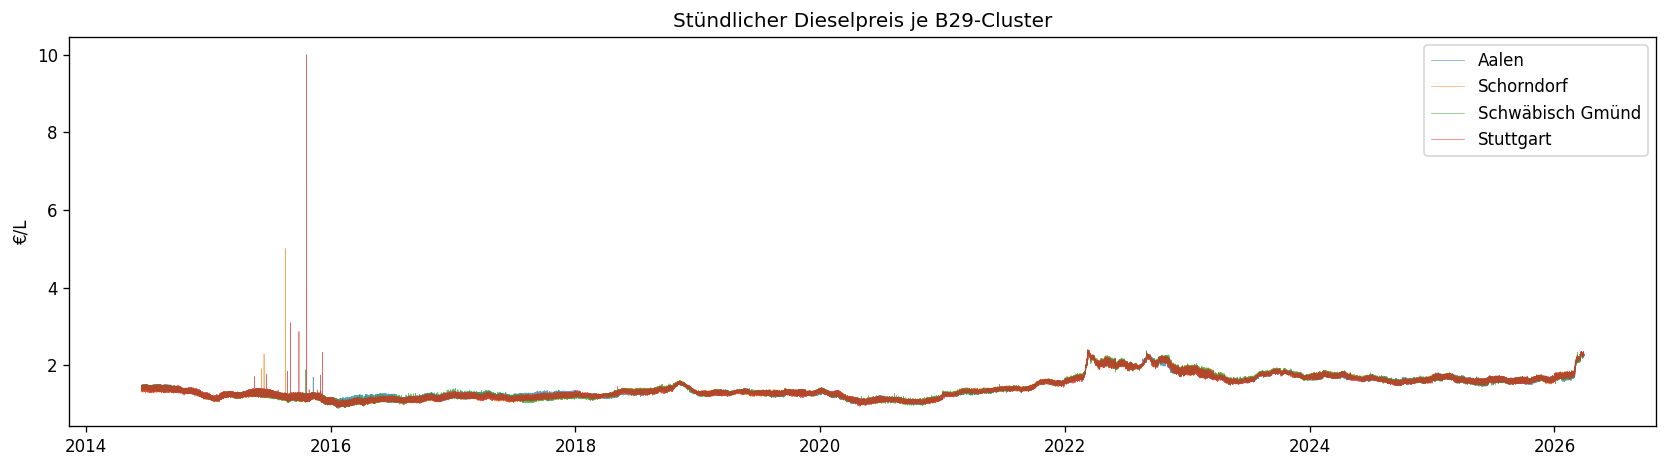

In [7]:
# Zeitlicher Verlauf
fig, ax = plt.subplots(figsize=(14, 4))
for col in y_t1.columns:
    ax.plot(y_t1.index, y_t1[col], lw=0.4, alpha=0.7, label=col.replace('diesel_', ''))
ax.set(title='Stündlicher Dieselpreis je B29-Cluster',
       ylabel='€/L', xlabel='')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
save_plot(plt, 'diesel_price_historical')
plt.show()

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-20-59_diesel_intraday_and_correlation_2.png


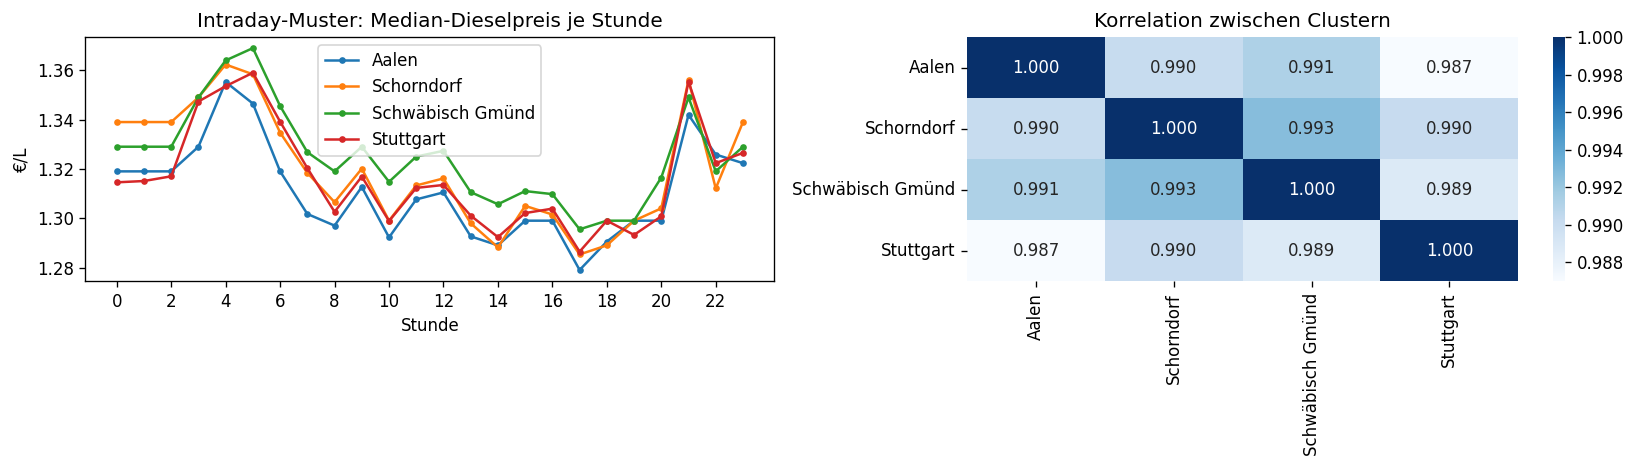

In [8]:
# Intraday-Muster und Cluster-Korrelation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Links: Intraday-Median
for col in y_t1.columns:
    intraday = y_t1[col].groupby(y_t1.index.hour).median()
    ax1.plot(intraday.index, intraday.values, marker='o', ms=3,
             label=col.replace('diesel_', ''))
ax1.set(title='Intraday-Muster: Median-Dieselpreis je Stunde',
        xlabel='Stunde', ylabel='€/L')
ax1.set_xticks(range(0, 24, 2))
ax1.legend()

# Rechts: Korrelations-Heatmap
labels = [c.replace('diesel_', '') for c in y_t1.columns]
sns.heatmap(y_t1.corr(), annot=True, fmt='.3f', cmap='Blues', ax=ax2,
            xticklabels=labels, yticklabels=labels)
ax2.set_title('Korrelation zwischen Clustern')

plt.tight_layout()
save_plot(plt, 'diesel_intraday_and_correlation')
plt.show()

---
## §3 Data Preparation
Der `B29DataLoader` hat bereits alle Features berechnet (Lags, Rolling, Trend, Momentum, Zeitmerkmale).  Hier prüfen wir die Feature-Matrix und führen den Temporal-Split durch.

### Zielvariable y — Multi-Output-Struktur

Das MLP löst ein **Multi-Output-Regressionsproblem**: Es sagt gleichzeitig alle Preise für **4 Cluster × 72 Stunden = 288 Ausgabe-Neuronen** voraus.

**Spaltenformat:** `{fuel}_{cluster}_t+{h}h`  
- `fuel` = Kraftstofftyp (hier: `diesel`)  
- `cluster` = Streckenabschnitt (`Aalen`, `Schwäbisch_Gmünd`, `Schorndorf`, `Stuttgart`)  
- `h` = Vorhersage-Horizont in Stunden (1 … 72)

**Beispiel-Spalten:**  
`diesel_Aalen_t+1h` → Dieselpreis in Aalen, 1 Stunde voraus  
`diesel_Stuttgart_t+72h` → Dieselpreis in Stuttgart, 72 Stunden (3 Tage) voraus

Das Modell lernt damit in einem einzigen Forward-Pass die komplette 72h-Preisentwicklung aller vier Cluster — sogenanntes **Direct Multi-Step Forecasting**.

In [9]:
# --- Target-Matrix: Struktur und Dimensionen ---
n_clusters = len(base_targets)
n_horizons = TARGET_HORIZON
n_outputs  = n_clusters * n_horizons

print(f'Target-Matrix y:  {y.shape[0]:,} Zeitpunkte × {y.shape[1]} Output-Spalten')
print(f'  → {n_clusters} Cluster × {n_horizons} Horizonte = {n_outputs} Output-Neuronen')
print()

# Spaltenstruktur zeigen: erste und letzte Spalten je Cluster
print('Spaltenstruktur (erste + letzte je Cluster):')
for cluster in base_targets:
    first = f'{cluster}_t+1h'
    last  = f'{cluster}_t+{TARGET_HORIZON}h'
    print(f'  {cluster:22s}: {first}  …  {last}')

# Beispielzeile: ein Zeitpunkt, alle 288 Targets
print(f'\nBeispielzeile (Zeitpunkt {y.index[100]}):')
sample = y.iloc[100]
for cluster in base_targets:
    cols_cluster = [c for c in y.columns if c.startswith(cluster)]
    vals = sample[cols_cluster]
    print(f'  {cluster:22s}:  t+1h={vals.iloc[0]:.4f}  t+24h={vals.iloc[23]:.4f}  '
          f't+48h={vals.iloc[47]:.4f}  t+72h={vals.iloc[-1]:.4f} €/L')

Target-Matrix y:  103,317 Zeitpunkte × 288 Output-Spalten
  → 4 Cluster × 72 Horizonte = 288 Output-Neuronen

Spaltenstruktur (erste + letzte je Cluster):
  diesel_Aalen          : diesel_Aalen_t+1h  …  diesel_Aalen_t+72h
  diesel_Schorndorf     : diesel_Schorndorf_t+1h  …  diesel_Schorndorf_t+72h
  diesel_Schwäbisch Gmünd: diesel_Schwäbisch Gmünd_t+1h  …  diesel_Schwäbisch Gmünd_t+72h
  diesel_Stuttgart      : diesel_Stuttgart_t+1h  …  diesel_Stuttgart_t+72h

Beispielzeile (Zeitpunkt 2014-06-20 04:00:00):
  diesel_Aalen          :  t+1h=1.3690  t+24h=1.3898  t+48h=1.3873  t+72h=1.3882 €/L
  diesel_Schorndorf     :  t+1h=1.3754  t+24h=1.3377  t+48h=1.3527  t+72h=1.3503 €/L
  diesel_Schwäbisch Gmünd:  t+1h=1.4090  t+24h=1.4230  t+48h=1.4190  t+72h=1.4240 €/L
  diesel_Stuttgart      :  t+1h=1.3957  t+24h=1.3680  t+48h=1.3827  t+72h=1.3858 €/L


Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-20-59_target_multi_output_structure_3.png


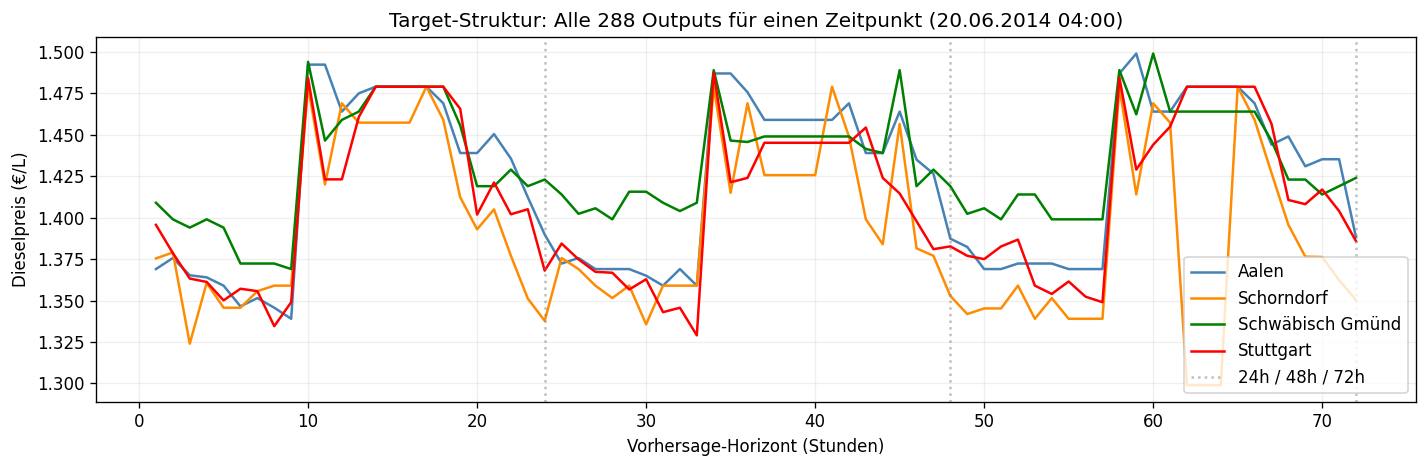

In [10]:
# Visualisierung: Multi-Output-Struktur — Preiskurve eines Zeitpunkts über alle Horizonte
sample_idx = y.index[100]
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green', 'red']

for cluster, color in zip(base_targets, colors):
    cols = [f'{cluster}_t+{h}h' for h in range(1, TARGET_HORIZON + 1)]
    vals = y.loc[sample_idx, cols].values
    label = cluster.replace('diesel_', '')
    ax.plot(range(1, TARGET_HORIZON + 1), vals, lw=1.5, color=color, label=label)

ax.set(title=f'Target-Struktur: Alle 288 Outputs für einen Zeitpunkt ({sample_idx.strftime("%d.%m.%Y %H:%M")})',
       xlabel='Vorhersage-Horizont (Stunden)', ylabel='Dieselpreis (€/L)')
ax.axvline(24, ls=':', color='gray', alpha=0.5, label='24h / 48h / 72h')
ax.axvline(48, ls=':', color='gray', alpha=0.5)
ax.axvline(72, ls=':', color='gray', alpha=0.5)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
save_plot(plt, 'target_multi_output_structure')
plt.show()

In [11]:
# Feature-Übersicht
print(f'Feature-Matrix X: {X.shape}')
print(f'Target-Matrix  y: {y.shape}')
print(f'Cluster: {len(base_targets)}, Horizonte je Cluster: {TARGET_HORIZON}')

# Feature-Gruppen zählen
groups = {
    'Lag-Features':     [c for c in X.columns if '_lag_' in c],
    'Price_t-Features': [c for c in X.columns if c.endswith('_price_t')],
    'Rolling-Features': [c for c in X.columns if '_roll_' in c],
    'Diff/Momentum':    [c for c in X.columns if '_diff' in c or '_momentum' in c],
    'Trend':            [c for c in X.columns if '_trend' in c],
    'Zeitmerkmale':     ['hour', 'day_of_week', 'is_weekend', 'is_holiday'],
}
print('\nFeature-Gruppen:')
for name, cols in groups.items():
    print(f'  {name:20s}: {len(cols):3d} Spalten')
print(f'  {"─"*20}──────────')
print(f'  {"Total":20s}: {X.shape[1]:3d} Spalten')

Feature-Matrix X: (103317, 80)
Target-Matrix  y: (103317, 288)
Cluster: 4, Horizonte je Cluster: 72

Feature-Gruppen:
  Lag-Features        :  36 Spalten
  Price_t-Features    :   4 Spalten
  Rolling-Features    :  24 Spalten
  Diff/Momentum       :   8 Spalten
  Trend               :   4 Spalten
  Zeitmerkmale        :   4 Spalten
  ──────────────────────────────
  Total               :  80 Spalten


In [12]:
# NaN-Check und Bereinigung
nan_count = X.isna().sum().sum()
print(f'NaN in X: {nan_count}  ({nan_count/X.size*100:.2f}%)')
if nan_count > 0:
    print('Spalten mit NaN:')
    print(X.isna().sum()[X.isna().sum() > 0])

# Verbleibende NaN-Zeilen entfernen
valid_idx = X.dropna().index.intersection(y.dropna().index)
X, y = X.loc[valid_idx], y.loc[valid_idx]
print(f'Bereinigte Größe: X={X.shape}, y={y.shape}')

NaN in X: 0  (0.00%)
Bereinigte Größe: X=(103317, 80), y=(103317, 288)


In [13]:
# Temporaler Split (kein Shuffle — Zeitreihen!)
X_train, X_val, X_test, y_train, y_val, y_test = loader.train_val_test_split(X, y)

# Skalierung (fit nur auf Train → kein Data Leakage)
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)

print('Scaler fitted auf Train-Set — kein Data Leakage.')

  Train : 2014-06-16 00:00:00  →  2021-12-31 23:00:00  (66,144 rows)
  Val   : 2022-01-01 00:00:00  →  2023-12-31 23:00:00  (17,520 rows)
  Test  : 2024-01-01 00:00:00  →  2026-03-29 20:00:00  (19,653 rows)
Scaler fitted auf Train-Set — kein Data Leakage.


---
## §4 Modeling
**Baselines:**- *Persistence-Baseline:* Aktueller Preis als Vorhersage für alle zukünftigen Stunden (naive Benchmark)

**Modell:**- *MLP (Multi-Layer Perceptron):* Direkte Mehrschritt-Vorhersage aller 4×72 = 288 Targets

In [14]:
# Cross-Validation mit TimeSeriesSplit
mlp_cv = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=False,
)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    mlp_cv, X_train_s, y_train_s,
    cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_mae = -cv_scores
print('TimeSeriesSplit CV (5 Folds) — MAE (skalierte Targets):')
print(f'  Folds : {np.round(cv_mae, 5)}')
print(f'  Mean  : {cv_mae.mean():.5f} ± {cv_mae.std():.5f}')

TimeSeriesSplit CV (5 Folds) — MAE (skalierte Targets):
  Folds : [0.24026 0.15872 0.20593 0.18076 0.1557 ]
  Mean  : 0.18828 ± 0.03164


In [15]:
# Finales Modell auf gesamtem Train-Set trainieren
model = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=True,
)
model.fit(X_train_s, y_train_s)
print(f'\nEffektive Epochen: {model.n_iter_}')
print(f'Final loss: {model.loss_:.6f}')

# MLP-Architektur bestätigen
n_in  = X_train_s.shape[1]
n_out = y_train_s.shape[1]
h1, h2 = model.hidden_layer_sizes
print(f'\nMLP-Architektur: {n_in} → [{h1}] → [{h2}] → {n_out}')
print(f'  Input-Neuronen : {n_in} (Features)')
print(f'  Hidden Layer 1 : {h1} Neuronen (ReLU)')
print(f'  Hidden Layer 2 : {h2} Neuronen (ReLU)')
print(f'  Output-Neuronen: {n_out} ({len(base_targets)} Cluster × {TARGET_HORIZON} Horizonte)')

Iteration 1, loss = 0.06704748
Validation score: 0.930639
Iteration 2, loss = 0.03704284
Validation score: 0.939034
Iteration 3, loss = 0.03403571
Validation score: 0.943760
Iteration 4, loss = 0.03226641
Validation score: 0.945822
Iteration 5, loss = 0.03157640
Validation score: 0.948024
Iteration 6, loss = 0.03064419
Validation score: 0.949351
Iteration 7, loss = 0.03003840
Validation score: 0.950442
Iteration 8, loss = 0.02958064
Validation score: 0.951491
Iteration 9, loss = 0.02914416
Validation score: 0.951698
Iteration 10, loss = 0.02884635
Validation score: 0.951582
Iteration 11, loss = 0.02862275
Validation score: 0.952685
Iteration 12, loss = 0.02833329
Validation score: 0.952857
Iteration 13, loss = 0.02800233
Validation score: 0.953889
Iteration 14, loss = 0.02777133
Validation score: 0.953231
Iteration 15, loss = 0.02753801
Validation score: 0.954093
Iteration 16, loss = 0.02729729
Validation score: 0.955121
Iteration 17, loss = 0.02703934
Validation score: 0.955408
Iterat

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-22-53_diesel_mlp_loss_curve_4.png


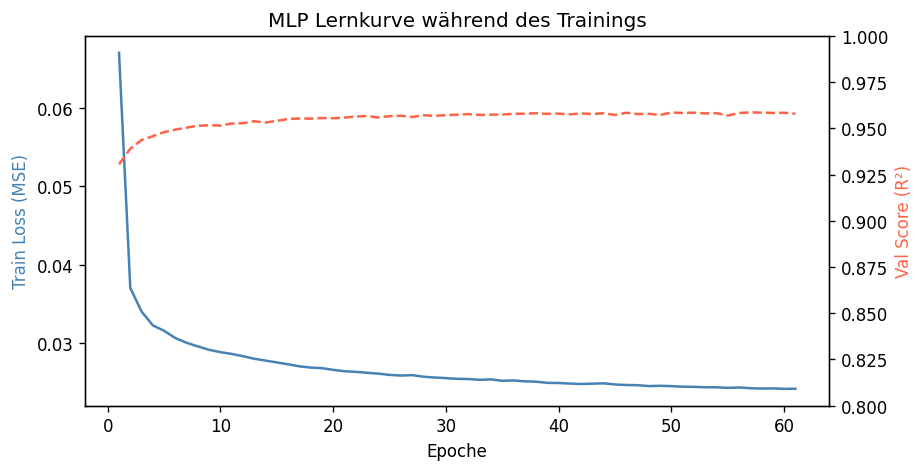

In [16]:
# Lernkurve visualisieren
epochs = np.arange(1, len(model.loss_curve_) + 1)
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(epochs, model.loss_curve_, color='steelblue', label='Train Loss (MSE)')
ax1.set_ylabel('Train Loss (MSE)', color='steelblue')

if hasattr(model, 'validation_scores_'):
    ax2 = ax1.twinx()
    ax2.plot(epochs[:len(model.validation_scores_)], model.validation_scores_,
             ls='--', color='tomato', label='Val Score (R²)')
    ax2.set_ylabel('Val Score (R²)', color='tomato')
    ax2.set_ylim(0.8, 1)

ax1.set_xlabel('Epoche')
plt.title('MLP Lernkurve während des Trainings')
save_plot(plt, 'diesel_mlp_loss_curve')
plt.show()

---
## §5 Evaluation (Test-Set — einmalig geöffnet)Vergleich des MLP mit der Persistence-Baseline auf dem ungesehenen Test-Set (2024–2026).

In [17]:
# Vorhersagen auf Test-Set
y_test_pred = scaler_y.inverse_transform(model.predict(X_test_s))
y_test_pred = pd.DataFrame(y_test_pred, index=y_test.index, columns=y.columns)

# Persistence-Baseline
persist_pred = build_persistence_baseline(X_test, y_test, base_targets, TARGET_HORIZON)

# Metriken je Horizont berechnen
test_metrics   = compute_metrics_by_horizon(y_test, y_test_pred, base_targets, TARGET_HORIZON)
persist_metrics = compute_metrics_by_horizon(y_test, persist_pred, base_targets, TARGET_HORIZON)

print_metrics_summary('MLP', test_metrics)
print_metrics_summary('Persistence', persist_metrics)


MLP — Performance je Horizont:
               MAE     RMSE       R2
horizon_h                           
1          0.02320  0.03005  0.93753
2          0.02445  0.03147  0.93143
3          0.02801  0.03592  0.91045
4          0.02530  0.03241  0.92728
5          0.02671  0.03453  0.91719
6          0.02447  0.03179  0.93012
...
               MAE     RMSE       R2
horizon_h                           
70         0.02340  0.03487  0.92338
71         0.02560  0.03740  0.91223
72         0.02656  0.03981  0.90118

MLP Gesamt (Ø): MAE=0.02686 €/L, RMSE=0.03643, R²=0.9113

Persistence — Performance je Horizont:
               MAE     RMSE       R2
horizon_h                           
1          0.02075  0.02815  0.94455
2          0.02358  0.03488  0.91512
3          0.03075  0.04093  0.88349
4          0.03358  0.04459  0.86191
5          0.03763  0.04763  0.84281
6          0.03813  0.04756  0.84338
...
               MAE     RMSE       R2
horizon_h                           
70         

In [18]:
# Gesamtvergleich MLP vs Persistence
comparison = pd.DataFrame({
    'MAE': [test_metrics['MAE'].mean(), persist_metrics['MAE'].mean()],
    'RMSE': [test_metrics['RMSE'].mean(), persist_metrics['RMSE'].mean()],
    'R2': [test_metrics['R2'].mean(), persist_metrics['R2'].mean()]
}, index=['MLP', 'Persistence'])

print('Gesamtvergleich (Ø über alle Horizonte):')
print(comparison.round(5))

mae_improv = (persist_metrics['MAE'].mean() - test_metrics['MAE'].mean()) / persist_metrics['MAE'].mean() * 100
rmse_skill = 1 - (test_metrics['RMSE'].mean() / persist_metrics['RMSE'].mean())
print(f'\nVerbesserung ggü. Persistence (MAE): {mae_improv:.1f}%')
print(f'RMSE Skill Score: {rmse_skill:.1%}')
print(f'Fleet-Kostenfehler/Tag (Ø-MAE): {test_metrics["MAE"].mean() * DAILY_LITERS:.2f} €')

Gesamtvergleich (Ø über alle Horizonte):
                 MAE     RMSE       R2
MLP          0.02686  0.03643  0.91127
Persistence  0.03816  0.04932  0.83360

Verbesserung ggü. Persistence (MAE): 29.6%
RMSE Skill Score: 26.1%
Fleet-Kostenfehler/Tag (Ø-MAE): 100.73 €


Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-22-53_mlp_vs_persistence_by_horizon_5.png


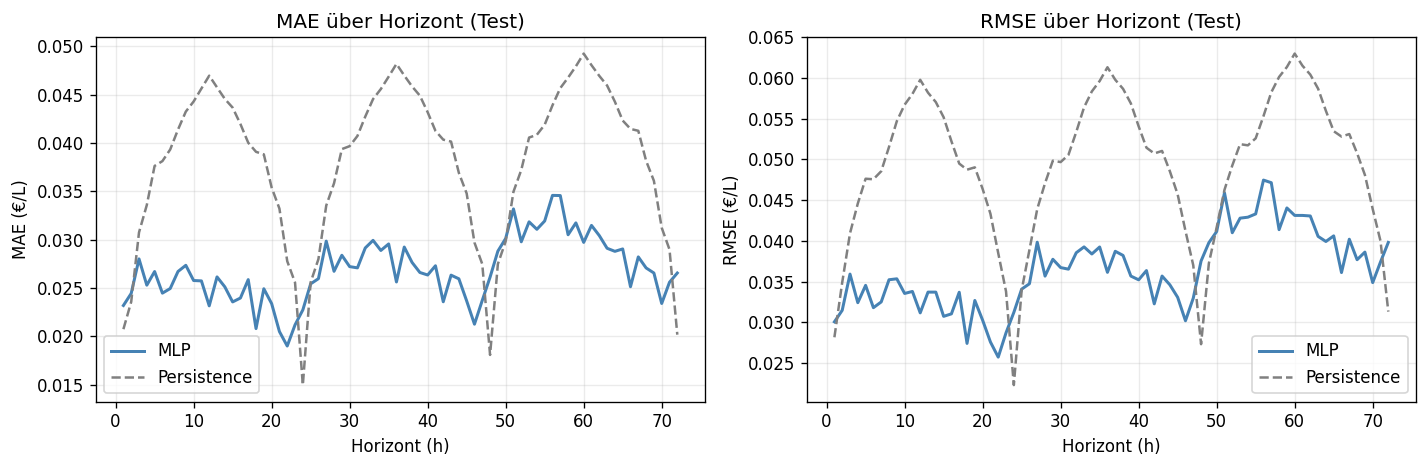

In [19]:
# MAE/RMSE über Horizont: MLP vs Persistence
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, metric, ylabel in zip(axes, ['MAE', 'RMSE'], ['MAE (€/L)', 'RMSE (€/L)']):
    ax.plot(test_metrics.index, test_metrics[metric], label='MLP', color='steelblue', lw=1.8)
    ax.plot(persist_metrics.index, persist_metrics[metric], label='Persistence',
            color='gray', lw=1.5, ls='--')
    ax.set(title=f'{metric} über Horizont (Test)', xlabel='Horizont (h)', ylabel=ylabel)
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
save_plot(plt, 'mlp_vs_persistence_by_horizon')
plt.show()

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-22-54_actual_vs_predicted_t1_6.png


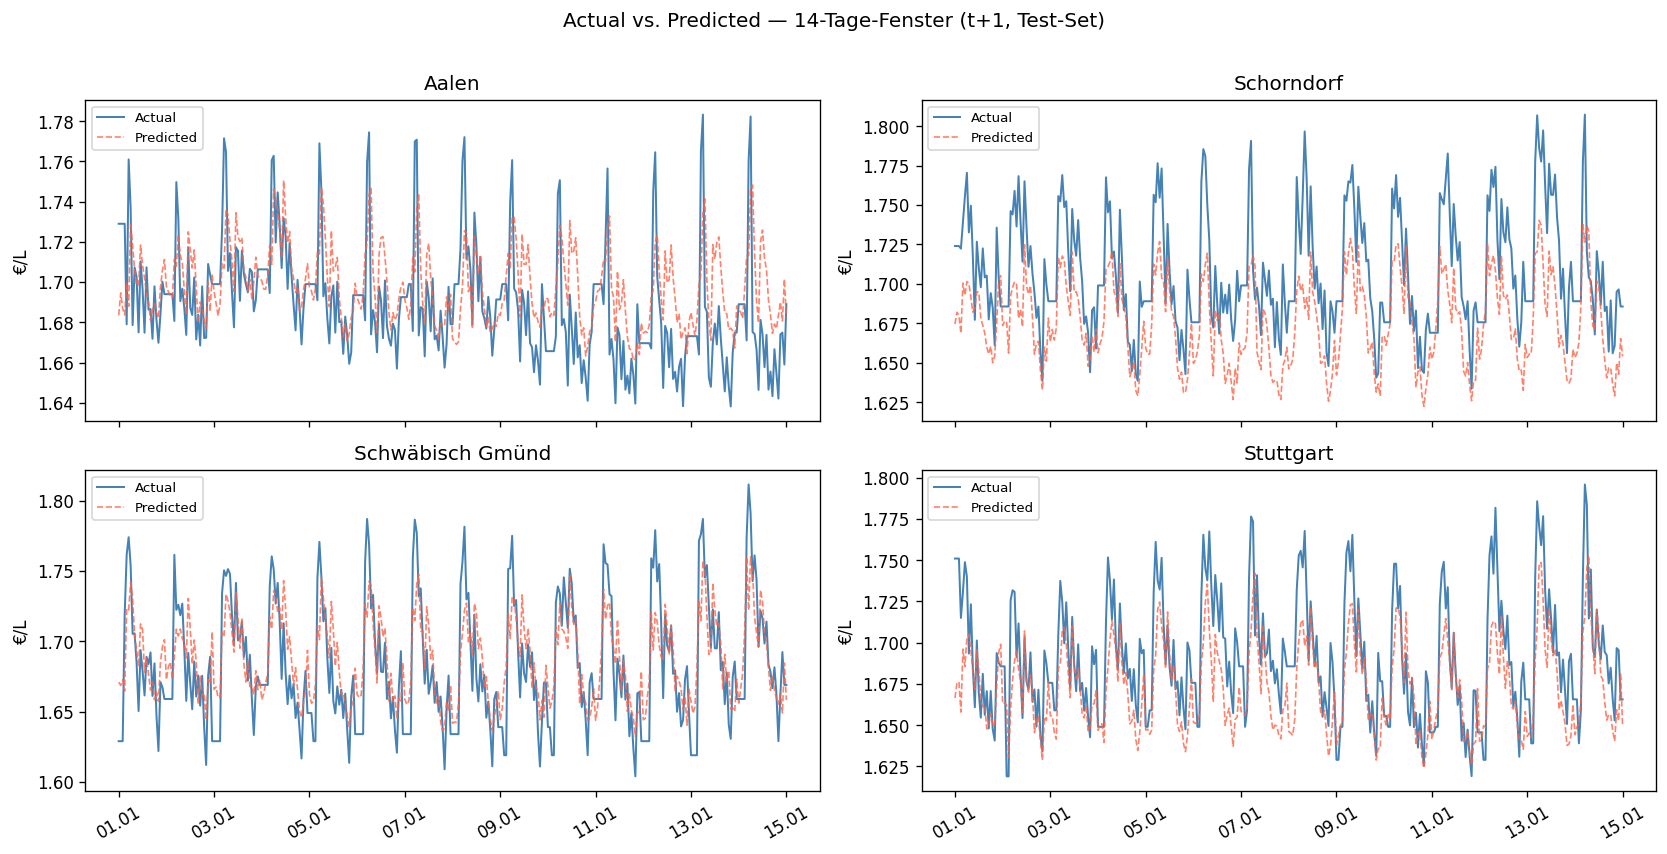

In [20]:
# Actual vs. Predicted — 14-Tage-Fenster (t+1)
y_test_t1 = y_test[[f'{c}_t+1h' for c in base_targets]].copy()
y_test_t1.columns = base_targets
y_pred_t1 = y_test_pred[[f'{c}_t+1h' for c in base_targets]].copy()
y_pred_t1.columns = base_targets

sample_end = y_test.index[0] + pd.Timedelta(days=14)
mask = y_test_t1.index <= sample_end

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, col in zip(axes.flat, y_test_t1.columns):
    ax.plot(y_test_t1.index[mask], y_test_t1.loc[mask, col], lw=1.2,
            label='Actual', color='steelblue')
    ax.plot(y_pred_t1.index[mask], y_pred_t1.loc[mask, col],
            lw=1, ls='--', label='Predicted', color='tomato', alpha=0.8)
    ax.set_title(col.replace('diesel_', ''))
    ax.set_ylabel('€/L')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Actual vs. Predicted — 14-Tage-Fenster (t+1, Test-Set)', y=1.01)
plt.tight_layout()
save_plot(plt, 'actual_vs_predicted_t1')
plt.show()

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-22-54_residuals_t1_7.png


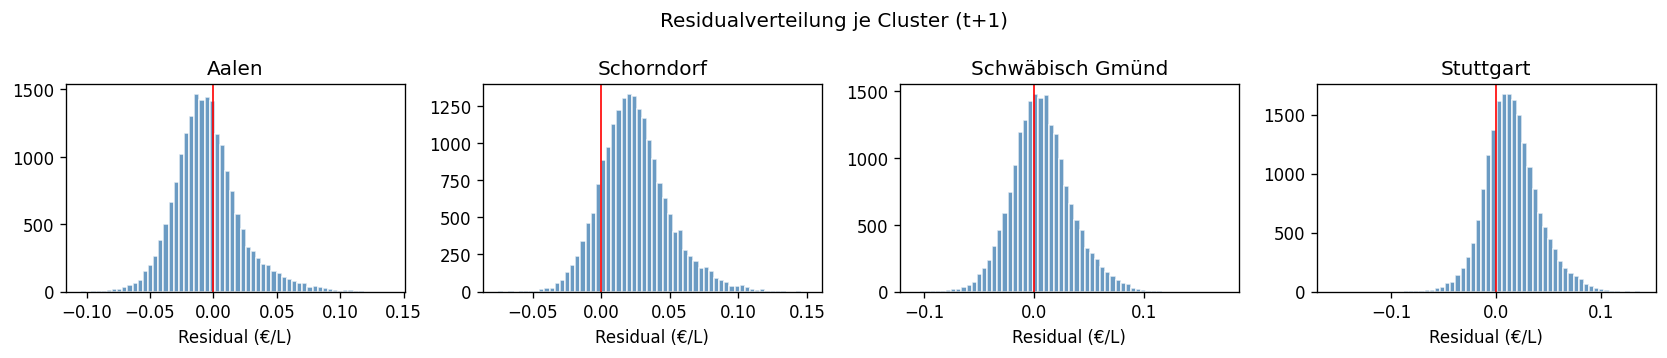

In [21]:
# Residualverteilung je Cluster (t+1)
residuals = y_test_t1 - y_pred_t1

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, residuals.columns):
    ax.hist(residuals[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', lw=1)
    ax.set_title(col.replace('diesel_', ''))
    ax.set_xlabel('Residual (€/L)')
fig.suptitle('Residualverteilung je Cluster (t+1)')
plt.tight_layout()
save_plot(plt, 'residuals_t1')
plt.show()

---## §6 Deployment: Direkte 72h-Forecast je B29-ClusterDirekte Vorhersage der nächsten 72 Stunden in einem Schritt.  Empfehlung: **Wo** und **wann** auf der B29 tanken?

In [22]:
def forecast_72h_direct(model, scaler_X, scaler_y, X_data, y_columns,
                         base_targets, horizon=72):
    """Direkte 72h-Vorhersage ab dem letzten bekannten Zeitpunkt."""
    x_last = X_data.iloc[[-1]]
    y_scaled = model.predict(scaler_X.transform(x_last))
    pred = pd.Series(scaler_y.inverse_transform(y_scaled)[0], index=y_columns)
    last_ts = X_data.index[-1]

    rows = []
    for step in range(1, horizon + 1):
        ts = last_ts + pd.Timedelta(hours=step)
        row = {'timestamp': ts}
        for cluster in base_targets:
            row[cluster] = pred[f'{cluster}_t+{step}h']
        rows.append(row)
    return pd.DataFrame(rows).set_index('timestamp')


df_forecast = forecast_72h_direct(
    model, scaler_X, scaler_y, X_test,
    y.columns.tolist(), base_targets, TARGET_HORIZON
)
print(f'Forecast: {df_forecast.shape}')
df_forecast.head()

Forecast: (72, 4)


,diesel_Aalen,diesel_Schorndorf,diesel_Schwäbisch Gmünd,diesel_Stuttgart
timestamp,,,,
2026-03-29 21:00:00,2.294554,2.211454,2.263351,2.241261
2026-03-29 22:00:00,2.248098,2.149759,2.244790,2.221317
2026-03-29 23:00:00,2.247918,2.165124,2.224712,2.211127
2026-03-30 00:00:00,2.303790,2.207792,2.264793,2.253100
2026-03-30 01:00:00,2.297827,2.219436,2.266611,2.247986


Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-13-22-55_forecast_72h_direct_8.png


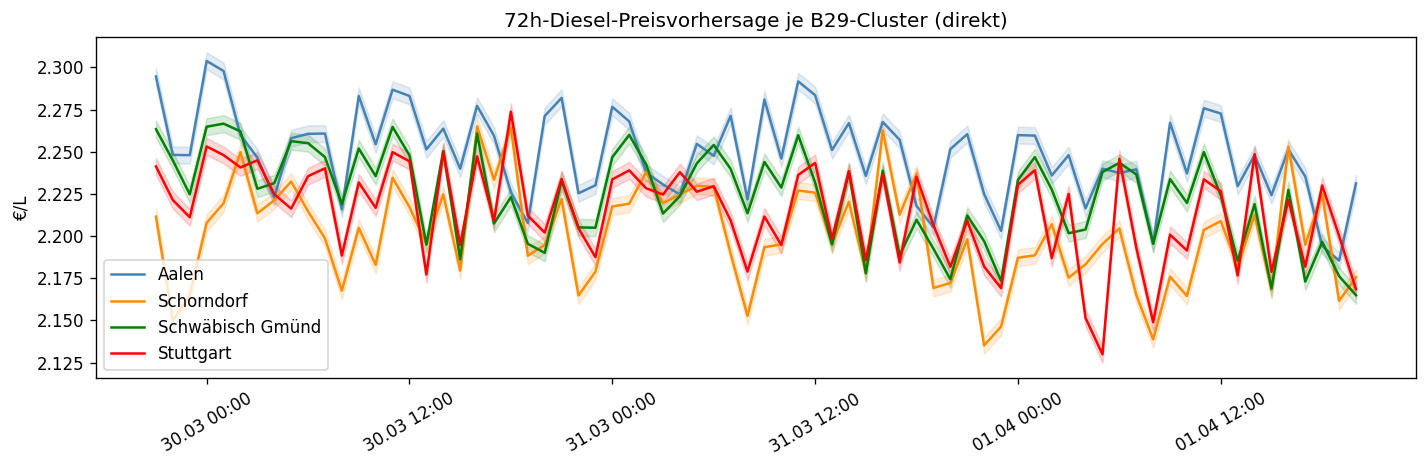

In [23]:
# 72h-Forecast visualisieren
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green', 'red']

for col, color in zip(df_forecast.columns, colors):
    label = col.replace('diesel_', '')
    ax.plot(df_forecast.index, df_forecast[col], lw=1.5, label=label, color=color)
    ax.fill_between(df_forecast.index, df_forecast[col] - 0.005,
                    df_forecast[col] + 0.005, alpha=0.15, color=color)

ax.set(title='72h-Diesel-Preisvorhersage je B29-Cluster (direkt)',
       ylabel='€/L', xlabel='')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
save_plot(plt, 'forecast_72h_direct')
plt.show()

In [24]:
# Tankempfehlung
min_price = df_forecast.min()
min_time  = df_forecast.idxmin()
best_col  = min_price.idxmin()
best_cluster = best_col.replace('diesel_', '')
best_time    = min_time[best_col]
best_price   = min_price.min()
current_avg  = df_forecast.iloc[0].mean()

print('=== Tankempfehlung für die nächsten 72 Stunden ===\n')
for col in df_forecast.columns:
    c = col.replace('diesel_', '')
    print(f'  {c:22s}: {df_forecast[col].min():.4f} €/L  um {df_forecast[col].idxmin().strftime("%d.%m.%Y %H:%M")}')

saving = (current_avg - best_price) * DAILY_LITERS
print(f'\n>>> Empfehlung: {best_cluster} um {best_time.strftime("%d.%m.%Y %H:%M")} Uhr')
print(f'    Günstigster Preis : {best_price:.4f} €/L')
print(f'    Jetziger Schnitt  : {current_avg:.4f} €/L')
print(f'    Einsparung/Tag    : {saving:.2f} € ({current_avg - best_price:.4f} €/L × {DAILY_LITERS:.0f} L)')

=== Tankempfehlung für die nächsten 72 Stunden ===

  Aalen                 : 2.1854 €/L  um 01.04.2026 19:00
  Schorndorf            : 2.1351 €/L  um 31.03.2026 22:00
  Schwäbisch Gmünd      : 2.1649 €/L  um 01.04.2026 20:00
  Stuttgart             : 2.1298 €/L  um 01.04.2026 05:00

>>> Empfehlung: Stuttgart um 01.04.2026 05:00 Uhr
    Günstigster Preis : 2.1298 €/L
    Jetziger Schnitt  : 2.2527 €/L
    Einsparung/Tag    : 460.56 € (0.1228 €/L × 3750 L)
